In [32]:
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2


def get_parent_dir():
    try:
        return Path(__file__).resolve().parent.parent
    except NameError:
        return Path.cwd().parent

parent_dir = str(get_parent_dir())
print("Parent directory:", parent_dir)

sys.path.append(parent_dir)
from models.mouse.setup_run_render import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parent directory: c:\Users\HP\ModellingProjects\Olivocerebellar-circuit


In [34]:
%autoreload
delta = [-1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1]

net, runner, data_path, video_path = init_and_run(
    delta,
    duration=5_000.0,
    seed=0,
    run_id=2,
    output_dir="mouse_runs",
    save_data =True,
    save_video=True,
    video_fps=30,
    video_playback_speed=1.0,
)

Saved MP4 (152 frames): mouse_runs\run_0002.mp4


In [ ]:
qpos = np.asarray(runner.mon["body"]["qpos"])  # radians
joint_range_deg = np.rad2deg(qpos.max(axis=0) - qpos.min(axis=0))

print("max movement p joint (degrees):")
print(np.round(joint_range_deg, 6))

print("\nlargest movement:", joint_range_deg.max(), "degrees")

Maximum movement per joint (degrees):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Largest movement: 0.0 degrees


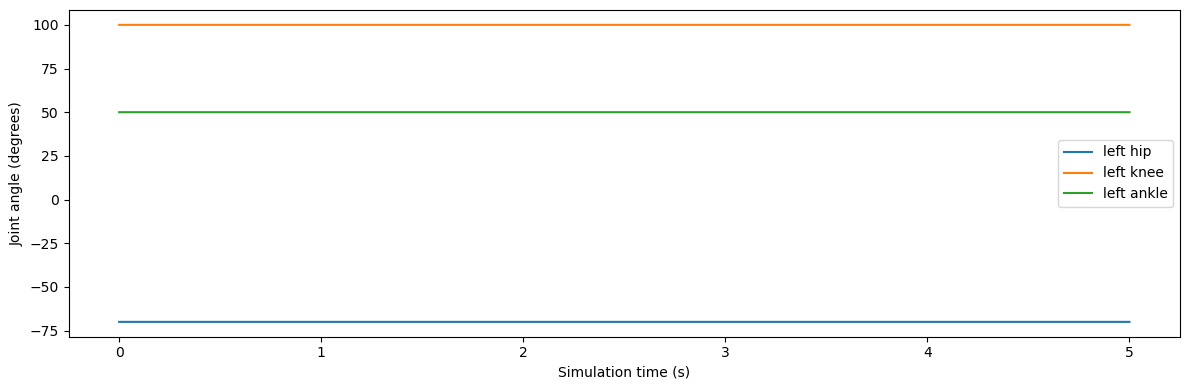

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

qpos = np.asarray(runner.mon["body"]["qpos"])
time_s = np.arange(len(qpos)) * runner.dt * 1e-3

plt.figure(figsize=(12, 4))
plt.plot(time_s, np.rad2deg(qpos[:, :3]))
plt.xlabel("Time (s)")
plt.ylabel("jointangle (degrees)")
plt.legend(["left hip", "left knee", "left ankle"])
plt.tight_layout()
plt.show()